#Install and Import Libraries

In [ ]:
# Imports
# ==========================================
import numpy as np
import pandas as pd
import os
from zipfile import ZipFile
from scipy.io import loadmat

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import EarlyStopping

import shap

#Load NASA and Oxford Data

In [ ]:
# =========================================================
#  Load NASA and Oxford Data
# =========================================================
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat

# -----------------------------------------
# Find files automatically inside /content
# -----------------------------------------
all_files = os.listdir("/content")

nasa_file = None
oxford_file = None

for f in all_files:
    fl = f.lower()
    if nasa_file is None and fl.endswith(".csv") and "battery_cycle_level" in fl:
        nasa_file = f
    if oxford_file is None and fl.endswith(".mat") and "oxford" in fl:
        oxford_file = f

print("NASA file found:", nasa_file)
print("Oxford file found:", oxford_file)

NASA_PATH = f"/content/{nasa_file}"
OXFORD_PATH = f"/content/{oxford_file}"

# -----------------------------------------
# Load NASA CSV
# -----------------------------------------
nasa_df = pd.read_csv(NASA_PATH)
nasa_df.columns = nasa_df.columns.str.lower()

nasa_df = nasa_df.rename(columns={
    "voltage_measured": "voltage",
    "temperature_measured": "temperature"
})

if "battery_id" not in nasa_df.columns:
    nasa_df["battery_id"] = "NASA_Battery"

nasa_df = nasa_df[["battery_id", "cycle", "voltage", "temperature", "capacity"]].copy()
nasa_df["battery_id"] = nasa_df["battery_id"].astype(str)
nasa_df["source"] = "NASA"

print("NASA loaded:", nasa_df.shape)
print("NASA batteries:", nasa_df["battery_id"].nunique())
display(nasa_df.head())

# -----------------------------------------
# Load Oxford MAT
# -----------------------------------------
def oxford_to_dataframe(mat):
    records = []

    for key in mat.keys():
        if "Cell" not in key:
            continue

        try:
            cell = mat[key][0, 0]

            for field_name in cell.dtype.names:
                cycle_data = cell[field_name][0, 0]

                def extract(arr, idx):
                    try:
                        return np.mean(arr[0, 0][idx])
                    except:
                        return np.nan

                v = extract(cycle_data["C1ch"], 1)
                t = extract(cycle_data["C1ch"], 3)
                q = extract(cycle_data["OCVch"], 1)

                if not np.isnan([v, t, q]).any():
                    records.append({
                        "battery_id": key,
                        "cycle": int(field_name.replace("cyc", "")),
                        "voltage": v,
                        "temperature": t,
                        "capacity": q
                    })
        except:
            continue

    return pd.DataFrame(records)

oxford_df = oxford_to_dataframe(loadmat(OXFORD_PATH))
oxford_df["battery_id"] = oxford_df["battery_id"].astype(str)
oxford_df["source"] = "Oxford"

print("Oxford loaded:", oxford_df.shape)
print("Oxford batteries:", oxford_df["battery_id"].nunique())
display(oxford_df.head())

NASA file found: battery_cycle_level_dataset_CLEAN_FINAL.csv
Oxford file found: Oxford_Battery_Degradation_Dataset_1.mat
NASA loaded: (1415, 6)
NASA batteries: 34


,battery_id,cycle,voltage,temperature,capacity,source
0,B0005,1,3.532781,32.536891,1.861976,NASA
1,B0005,2,3.542968,32.643595,1.851862,NASA
2,B0005,3,3.553056,32.522526,1.840808,NASA
3,B0005,4,3.545849,32.492083,1.850058,NASA
4,B0005,5,3.544456,32.368612,1.849432,NASA


Oxford loaded: (519, 6)
Oxford batteries: 8


,battery_id,cycle,voltage,temperature,capacity,source
0,Cell1,0,3.819664,40.049519,3.793972,Oxford
1,Cell1,100,3.821715,39.993983,3.794674,Oxford
2,Cell1,200,3.822391,39.992577,3.795319,Oxford
3,Cell1,300,3.822893,40.006883,3.796328,Oxford
4,Cell1,400,3.823835,39.988917,3.797030,Oxford


#Merge and Clean the Dataset

In [ ]:
# =========================================================
#  Merge and Clean the Dataset
# =========================================================
data = pd.concat([nasa_df, oxford_df], ignore_index=True)

# Keep only essential columns first
required_cols = ["battery_id", "cycle", "capacity"]
data = data.dropna(subset=required_cols).copy()

# Convert to proper types
data["battery_id"] = data["battery_id"].astype(str)
data["cycle"] = pd.to_numeric(data["cycle"], errors="coerce")
data["capacity"] = pd.to_numeric(data["capacity"], errors="coerce")
data["voltage"] = pd.to_numeric(data["voltage"], errors="coerce")
data["temperature"] = pd.to_numeric(data["temperature"], errors="coerce")

data = data.dropna(subset=["battery_id", "cycle", "capacity"]).copy()
data = data.sort_values(["battery_id", "cycle"]).reset_index(drop=True)

# Fill missing voltage and temperature within each battery
data["voltage"] = data.groupby("battery_id")["voltage"].transform(lambda x: x.interpolate().bfill().ffill())
data["temperature"] = data.groupby("battery_id")["temperature"].transform(lambda x: x.interpolate().bfill().ffill())

print("Total samples:", len(data))
print("Total batteries:", data["battery_id"].nunique())

battery_counts = data["battery_id"].value_counts()
print(battery_counts.head(50))

display(data.head())

Total samples: 1934
Total batteries: 42
battery_id
B0005    168
B0007    168
B0006    155
B0018    132
B0042     99
Cell1     78
Cell7     77
Cell3     76
Cell8     76
Cell2     73
B0045     70
B0046     69
B0048     69
B0047     69
B0044     66
B0043     66
Cell4     47
Cell5     46
Cell6     46
B0053     45
B0030     34
B0029     32
B0032     29
B0028     27
B0041     25
B0031     21
B0026     18
B0027     14
B0039     11
B0049      8
B0025      5
B0033      3
B0050      2
B0040      2
B0038      1
B0034      1
B0036      1
B0056      1
B0051      1
B0055      1
B0054      1
B0052      1
Name: count, dtype: int64


,battery_id,cycle,voltage,temperature,capacity,source
0,B0005,1,3.532781,32.536891,1.861976,NASA
1,B0005,2,3.542968,32.643595,1.851862,NASA
2,B0005,3,3.553056,32.522526,1.840808,NASA
3,B0005,4,3.545849,32.492083,1.850058,NASA
4,B0005,5,3.544456,32.368612,1.849432,NASA


#Create SOH and RUL and Engineered Features

In [ ]:
# =========================================================
#  Create SOH, RUL, and Enhanced Features
# =========================================================

data["battery_id"] = data["battery_id"].astype(str)
data["cycle"] = pd.to_numeric(data["cycle"], errors="coerce")
data["voltage"] = pd.to_numeric(data["voltage"], errors="coerce")
data["temperature"] = pd.to_numeric(data["temperature"], errors="coerce")
data["capacity"] = pd.to_numeric(data["capacity"], errors="coerce")

data = data.dropna(subset=["battery_id", "cycle", "voltage", "temperature", "capacity"]).copy()
data = data.sort_values(["battery_id", "cycle"]).reset_index(drop=True)

# Targets
initial_capacity = data.groupby("battery_id")["capacity"].transform("first")
max_cycle = data.groupby("battery_id")["cycle"].transform("max")

data["SOH"] = (data["capacity"] / initial_capacity).clip(0, 1.2)
data["RUL"] = (max_cycle - data["cycle"]).clip(lower=0)

# Basic difference features
data["capacity_change"] = data.groupby("battery_id")["capacity"].diff().fillna(0)
data["voltage_change"] = data.groupby("battery_id")["voltage"].diff().fillna(0)
data["temp_change"] = data.groupby("battery_id")["temperature"].diff().fillna(0)

# Rolling mean features
data["cap_roll_mean_5"] = data.groupby("battery_id")["capacity"].transform(
    lambda x: x.rolling(5, min_periods=1).mean()
)
data["volt_roll_mean_5"] = data.groupby("battery_id")["voltage"].transform(
    lambda x: x.rolling(5, min_periods=1).mean()
)
data["temp_roll_mean_5"] = data.groupby("battery_id")["temperature"].transform(
    lambda x: x.rolling(5, min_periods=1).mean()
)

# Rolling std features
data["cap_roll_std_5"] = data.groupby("battery_id")["capacity"].transform(
    lambda x: x.rolling(5, min_periods=1).std().fillna(0)
)
data["volt_roll_std_5"] = data.groupby("battery_id")["voltage"].transform(
    lambda x: x.rolling(5, min_periods=1).std().fillna(0)
)
data["temp_roll_std_5"] = data.groupby("battery_id")["temperature"].transform(
    lambda x: x.rolling(5, min_periods=1).std().fillna(0)
)

# Relative and interaction features
data["capacity_ratio"] = data["capacity"] / initial_capacity
data["cycle_ratio"] = data["cycle"] / max_cycle.replace(0, 1)
data["volt_temp_interaction"] = data["voltage"] * data["temperature"]
data["capacity_voltage_interaction"] = data["capacity"] * data["voltage"]

# Final feature list
feature_cols = [
    "cycle", "voltage", "temperature", "capacity",
    "capacity_change", "voltage_change", "temp_change",
    "cap_roll_mean_5", "volt_roll_mean_5", "temp_roll_mean_5",
    "cap_roll_std_5", "volt_roll_std_5", "temp_roll_std_5",
    "capacity_ratio", "cycle_ratio",
    "volt_temp_interaction", "capacity_voltage_interaction"
]

print(data[["battery_id", "cycle", "SOH", "RUL"]].head())
print("Final samples:", len(data))
print("Final batteries:", data["battery_id"].nunique())
print("Number of features:", len(feature_cols))
print(feature_cols)

  battery_id  cycle       SOH  RUL
0      B0005      1  1.000000  167
1      B0005      2  0.994568  166
2      B0005      3  0.988631  165
3      B0005      4  0.993599  164
4      B0005      5  0.993263  163
Final samples: 1934
Final batteries: 42
Number of features: 17
['cycle', 'voltage', 'temperature', 'capacity', 'capacity_change', 'voltage_change', 'temp_change', 'cap_roll_mean_5', 'volt_roll_mean_5', 'temp_roll_mean_5', 'cap_roll_std_5', 'volt_roll_std_5', 'temp_roll_std_5', 'capacity_ratio', 'cycle_ratio', 'volt_temp_interaction', 'capacity_voltage_interaction']


#Train/ Validation/ Test Split

In [ ]:
# ==========================================
# Train Test Split
# ==========================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(data, groups=data["battery_id"]))

train_df = data.iloc[train_idx].copy()
test_df = data.iloc[test_idx].copy()

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, val_idx = next(gss_val.split(train_df, groups=train_df["battery_id"]))

final_train_df = train_df.iloc[tr_idx].copy()
val_df = train_df.iloc[val_idx].copy()

print("Train batteries:", final_train_df["battery_id"].nunique())
print("Validation batteries:", val_df["battery_id"].nunique())
print("Test batteries:", test_df["battery_id"].nunique())

print("Train samples:", len(final_train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

Train batteries: 26
Validation batteries: 7
Test batteries: 9
Train samples: 1263
Validation samples: 365
Test samples: 306


#Define Leakage-Safe Feature Sets

In [ ]:
# =========================================================
#  Define Leakage-Safe Feature Sets
# =========================================================

# Feature set for SOH prediction
# We exclude features that directly reveal the SOH target
feature_cols_soh = [
    "cycle",
    "voltage",
    "temperature",
    "capacity_change",
    "voltage_change",
    "temp_change",
    "cap_roll_mean_5",
    "volt_roll_mean_5",
    "temp_roll_mean_5",
    "cap_roll_std_5",
    "volt_roll_std_5",
    "temp_roll_std_5",
    "cycle_ratio",
    "volt_temp_interaction"
]

# Feature set for RUL prediction
# We exclude cycle-based features that directly reveal the RUL target
feature_cols_rul = [
    "voltage",
    "temperature",
    "capacity",
    "capacity_change",
    "voltage_change",
    "temp_change",
    "cap_roll_mean_5",
    "volt_roll_mean_5",
    "temp_roll_mean_5",
    "cap_roll_std_5",
    "volt_roll_std_5",
    "temp_roll_std_5",
    "capacity_ratio",
    "volt_temp_interaction",
    "capacity_voltage_interaction"
]

print("SOH feature set:")
print(feature_cols_soh)
print("Number of SOH features:", len(feature_cols_soh))

print("\nRUL feature set:")
print(feature_cols_rul)
print("Number of RUL features:", len(feature_cols_rul))

SOH feature set:
['cycle', 'voltage', 'temperature', 'capacity_change', 'voltage_change', 'temp_change', 'cap_roll_mean_5', 'volt_roll_mean_5', 'temp_roll_mean_5', 'cap_roll_std_5', 'volt_roll_std_5', 'temp_roll_std_5', 'cycle_ratio', 'volt_temp_interaction']
Number of SOH features: 14

RUL feature set:
['voltage', 'temperature', 'capacity', 'capacity_change', 'voltage_change', 'temp_change', 'cap_roll_mean_5', 'volt_roll_mean_5', 'temp_roll_mean_5', 'cap_roll_std_5', 'volt_roll_std_5', 'temp_roll_std_5', 'capacity_ratio', 'volt_temp_interaction', 'capacity_voltage_interaction']
Number of RUL features: 15


#Scale Tabular Data

In [ ]:
# ==========================================
# Scale Tabular Data
# ==========================================

scaler_tab = StandardScaler()

X_train_tab = scaler_tab.fit_transform(final_train_df[feature_cols])
X_val_tab = scaler_tab.transform(val_df[feature_cols])
X_test_tab = scaler_tab.transform(test_df[feature_cols])

y_train_soh = final_train_df["SOH"].values
y_val_soh = val_df["SOH"].values
y_test_soh = test_df["SOH"].values

y_train_rul = final_train_df["RUL"].values
y_val_rul = val_df["RUL"].values
y_test_rul = test_df["RUL"].values

print("X_train_tab shape:", X_train_tab.shape)
print("X_val_tab shape:", X_val_tab.shape)
print("X_test_tab shape:", X_test_tab.shape)

X_train_tab shape: (1263, 17)
X_val_tab shape: (365, 17)
X_test_tab shape: (306, 17)


#Train Baseline Models (Random Forest & XGBoost)

In [ ]:
# =========================================================
#  Train Baseline Models with Hyperparameters
# =========================================================

rf_soh = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_rul = RandomForestRegressor(
    n_estimators=300,
    max_depth=14,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

xgb_soh = XGBRegressor(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42
)

xgb_rul = XGBRegressor(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42
)

rf_soh.fit(X_train_tab, y_train_soh)
rf_rul.fit(X_train_tab, y_train_rul)

xgb_soh.fit(X_train_tab, y_train_soh)
xgb_rul.fit(X_train_tab, y_train_rul)

rf_soh_pred = rf_soh.predict(X_test_tab)
rf_rul_pred = rf_rul.predict(X_test_tab)

xgb_soh_pred = xgb_soh.predict(X_test_tab)
xgb_rul_pred = xgb_rul.predict(X_test_tab)

print("Baseline models trained successfully")

Baseline models trained successfully


#Prepare Sequence Data

In [ ]:
# =========================================================
#  Prepare Sequence Data and Apply Data Augmentation
# =========================================================

SEQ_LEN = 20

def create_sequences(df, seq_len, feature_cols):
    X_seq, y_seq, battery_ids = [], [], []

    for battery_id, group in df.groupby("battery_id"):
        group = group.sort_values("cycle").reset_index(drop=True)

        if len(group) <= seq_len:
            continue

        X_values = group[feature_cols].values
        y_values = group[["SOH", "RUL"]].values

        for i in range(seq_len, len(group)):
            X_seq.append(X_values[i-seq_len:i])
            y_seq.append(y_values[i])
            battery_ids.append(battery_id)

    return np.array(X_seq), np.array(y_seq), np.array(battery_ids)

def augment_sequences(X, y):
    X_aug, y_aug = [], []

    for i in range(len(X)):
        seq = X[i]
        target = y[i]

        noise = np.random.normal(0, 0.01, seq.shape)
        seq_noisy = seq + noise

        scale = np.random.uniform(0.98, 1.02)
        seq_scaled = seq * scale

        X_aug.append(seq_noisy)
        y_aug.append(target)

        X_aug.append(seq_scaled)
        y_aug.append(target)

    X_final = np.concatenate([X, np.array(X_aug)], axis=0)
    y_final = np.concatenate([y, np.array(y_aug)], axis=0)

    return X_final, y_final

# Scale data for sequence models
scaler_seq = StandardScaler()
scaler_seq.fit(final_train_df[feature_cols])

train_seq_df = final_train_df.copy()
val_seq_df = val_df.copy()
test_seq_df = test_df.copy()

train_seq_df[feature_cols] = scaler_seq.transform(train_seq_df[feature_cols])
val_seq_df[feature_cols] = scaler_seq.transform(val_seq_df[feature_cols])
test_seq_df[feature_cols] = scaler_seq.transform(test_seq_df[feature_cols])

# Create sequences
X_train_seq, y_train_seq, train_seq_batteries = create_sequences(train_seq_df, SEQ_LEN, feature_cols)
X_val_seq, y_val_seq, val_seq_batteries = create_sequences(val_seq_df, SEQ_LEN, feature_cols)
X_test_seq, y_test_seq, test_seq_batteries = create_sequences(test_seq_df, SEQ_LEN, feature_cols)

# Apply data augmentation only to training data
X_train_seq_aug, y_train_seq_aug = augment_sequences(X_train_seq, y_train_seq)

print("Train sequence shape:", X_train_seq.shape)
print("Validation sequence shape:", X_val_seq.shape)
print("Test sequence shape:", X_test_seq.shape)
print("Augmented train sequence shape:", X_train_seq_aug.shape)

Train sequence shape: (927, 20, 17)
Validation sequence shape: (225, 20, 17)
Test sequence shape: (191, 20, 17)
Augmented train sequence shape: (2781, 20, 17)


#Train Advanced Sequence Models (GRU and Improved BiLSTM with Attention)

In [ ]:
# =========================================================
#  Train Advanced Sequence Models (GRU and Improved BiLSTM with Attention)
# =========================================================

def build_gru_model(seq_len, n_features):
    inputs = Input(shape=(seq_len, n_features))
    x = GRU(64, return_sequences=True)(inputs)
    x = Dropout(0.25)(x)
    x = GRU(32)(x)
    x = Dense(32, activation="relu")(x)
    outputs = Dense(2)(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=tf.keras.losses.Huber(),
        metrics=["mae"]
    )
    return model

def build_bilstm_attention_model(seq_len, n_features):
    inputs = Input(shape=(seq_len, n_features))

    x = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    x = Dropout(0.25)(x)

    x = Bidirectional(LSTM(32, return_sequences=True))(x)
    x = Dropout(0.20)(x)

    attn = MultiHeadAttention(num_heads=2, key_dim=16)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization()(x)

    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.20)(x)

    outputs = Dense(2)(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=tf.keras.losses.Huber(),
        metrics=["mae"]
    )
    return model

callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
]

gru_model = build_gru_model(SEQ_LEN, len(feature_cols))
gru_history = gru_model.fit(
    X_train_seq_aug, y_train_seq_aug,
    validation_data=(X_val_seq, y_val_seq),
    epochs=40,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

bilstm_model = build_bilstm_attention_model(SEQ_LEN, len(feature_cols))
bilstm_history = bilstm_model.fit(
    X_train_seq_aug, y_train_seq_aug,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

gru_pred = gru_model.predict(X_test_seq)
bilstm_pred = bilstm_model.predict(X_test_seq)

print("Advanced sequence models trained successfully")

Epoch 1/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - loss: 312.6131 - mae: 312.9370 - val_loss: 751.8750 - val_mae: 752.1486
Epoch 2/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 306.6556 - mae: 306.9374 - val_loss: 749.0862 - val_mae: 749.3718
Epoch 3/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 299.8698 - mae: 300.1542 - val_loss: 740.5931 - val_mae: 740.8679
Epoch 4/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 291.4901 - mae: 291.7647 - val_loss: 732.5692 - val_mae: 732.8442
Epoch 5/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 285.3487 - mae: 285.6229 - val_loss: 722.0176 - val_mae: 722.2784
Epoch 6/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 279.5699 - mae: 279.8376 - val_loss: 710.6631 - val_mae: 710.9459
Epoch 7/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 273.3832 - mae: 273.6442 - val_loss: 696.8694 - val_mae: 697.1291
Epoch 8/40
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 266.4341 - mae: 266.6945 - val_loss: 680.6999 - val_mae: 680.9598


#Compare Baseline and Advanced Model Results

In [ ]:
# =========================================================
# - Compare Baseline and Advanced Model Results
# =========================================================

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def metrics_row(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

# SOH comparison
soh_results_table = pd.DataFrame([
    metrics_row("Random Forest", y_test_soh, rf_soh_pred),
    metrics_row("XGBoost", y_test_soh, xgb_soh_pred),
    metrics_row("GRU", y_test_seq[:, 0], gru_pred[:, 0]),
    metrics_row("Improved BiLSTM + Attention", y_test_seq[:, 0], bilstm_pred[:, 0])
]).sort_values("R2", ascending=False).reset_index(drop=True)

# RUL comparison
rul_results_table = pd.DataFrame([
    metrics_row("Random Forest", y_test_rul, rf_rul_pred),
    metrics_row("XGBoost", y_test_rul, xgb_rul_pred),
    metrics_row("GRU", y_test_seq[:, 1], gru_pred[:, 1]),
    metrics_row("Improved BiLSTM + Attention", y_test_seq[:, 1], bilstm_pred[:, 1])
]).sort_values("R2", ascending=False).reset_index(drop=True)

print("SOH Results")
display(soh_results_table)

print("RUL Results")
display(rul_results_table)

SOH Results


,Model,RMSE,MAE,R2
0,Random Forest,0.000646,0.000385,0.999976
1,XGBoost,0.017574,0.009445,0.982035
2,GRU,0.126327,0.099945,0.140969
3,Improved BiLSTM + Attention,0.280867,0.238769,-3.246348


RUL Results


,Model,RMSE,MAE,R2
0,Random Forest,45.085807,17.743759,0.998223
1,GRU,48.235907,19.190451,0.993126
2,XGBoost,120.610333,32.759308,0.987283
3,Improved BiLSTM + Attention,605.236500,212.505281,-0.082239


#Improve Deep Learning Models with New Hyperparameters

In [ ]:
# =========================================================
#  Improve Deep Learning Models with New Hyperparameters
# =========================================================
# Note:
# The first deep learning models did not outperform the baseline models,
# so a second version was trained using improved hyperparameters.

def build_improved_gru_model(seq_len, n_features):
    inputs = Input(shape=(seq_len, n_features))

    x = GRU(128, return_sequences=True)(inputs)
    x = Dropout(0.30)(x)

    x = GRU(64)(x)
    x = Dropout(0.20)(x)

    x = Dense(64, activation="relu")(x)
    x = Dense(32, activation="relu")(x)

    outputs = Dense(2)(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss=tf.keras.losses.Huber(),
        metrics=["mae"]
    )
    return model

def build_improved_bilstm_model(seq_len, n_features):
    inputs = Input(shape=(seq_len, n_features))

    x = Bidirectional(LSTM(128, return_sequences=True))(inputs)
    x = Dropout(0.30)(x)

    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Dropout(0.25)(x)

    attn = MultiHeadAttention(num_heads=4, key_dim=16)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization()(x)

    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.20)(x)
    x = Dense(32, activation="relu")(x)

    outputs = Dense(2)(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss=tf.keras.losses.Huber(),
        metrics=["mae"]
    )
    return model

callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
]

gru_model_v2 = build_improved_gru_model(SEQ_LEN, X_train_seq_aug.shape[2])
gru_history_v2 = gru_model_v2.fit(
    X_train_seq_aug, y_train_seq_aug,
    validation_data=(X_val_seq, y_val_seq),
    epochs=60,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

bilstm_model_v2 = build_improved_bilstm_model(SEQ_LEN, X_train_seq_aug.shape[2])
bilstm_history_v2 = bilstm_model_v2.fit(
    X_train_seq_aug, y_train_seq_aug,
    validation_data=(X_val_seq, y_val_seq),
    epochs=60,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

gru_pred_v2 = gru_model_v2.predict(X_test_seq)
bilstm_pred_v2 = bilstm_model_v2.predict(X_test_seq)

print("Improved deep learning models trained successfully")

Epoch 1/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - loss: 308.9211 - mae: 309.2838 - val_loss: 745.4006 - val_mae: 745.7117
Epoch 2/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - loss: 280.1731 - mae: 280.5069 - val_loss: 661.7887 - val_mae: 662.0920
Epoch 3/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 223.0554 - mae: 223.3778 - val_loss: 509.0097 - val_mae: 509.3908
Epoch 4/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 177.1908 - mae: 177.5183 - val_loss: 435.1212 - val_mae: 435.4022
Epoch 5/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 160.9158 - mae: 161.2410 - val_loss: 371.9715 - val_mae: 372.3578
Epoch 6/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 182.3013 - mae: 182.6325 - val_loss: 355.2457 - val_mae: 355.5183
Epoch 7/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 133.7805 - mae: 134.1077 - val_loss: 266.1669 - val_mae: 266.5183
Epoch 8/60
174/174 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 125.4139 - mae: 125.7406 - val_loss: 264.9459 -

#Compare Baseline Models with Improved Deep Learning Models

In [ ]:
# =========================================================
#  Compare Baseline Models with Improved Deep Learning Models
# =========================================================

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def metrics_row(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

# SOH comparison
soh_results_table_v2 = pd.DataFrame([
    metrics_row("Random Forest", y_test_soh, rf_soh_pred),
    metrics_row("XGBoost", y_test_soh, xgb_soh_pred),
    metrics_row("Improved GRU", y_test_seq[:, 0], gru_pred_v2[:, 0]),
    metrics_row("Improved BiLSTM + Attention", y_test_seq[:, 0], bilstm_pred_v2[:, 0])
]).sort_values("R2", ascending=False).reset_index(drop=True)

# RUL comparison
rul_results_table_v2 = pd.DataFrame([
    metrics_row("Random Forest", y_test_rul, rf_rul_pred),
    metrics_row("XGBoost", y_test_rul, xgb_rul_pred),
    metrics_row("Improved GRU", y_test_seq[:, 1], gru_pred_v2[:, 1]),
    metrics_row("Improved BiLSTM + Attention", y_test_seq[:, 1], bilstm_pred_v2[:, 1])
]).sort_values("R2", ascending=False).reset_index(drop=True)

print("SOH Results - Final Comparison")
display(soh_results_table_v2)

print("RUL Results - Final Comparison")
display(rul_results_table_v2)

SOH Results - Final Comparison


,Model,RMSE,MAE,R2
0,Random Forest,0.000646,0.000385,0.999976
1,XGBoost,0.017574,0.009445,0.982035
2,Improved GRU,0.171772,0.127909,-0.588250
3,Improved BiLSTM + Attention,0.369976,0.256337,-6.368200


RUL Results - Final Comparison


,Model,RMSE,MAE,R2
0,Random Forest,45.085807,17.743759,0.998223
1,Improved GRU,52.712669,24.530670,0.991791
2,XGBoost,120.610333,32.759308,0.987283
3,Improved BiLSTM + Attention,120.375368,45.328673,0.957190


#Visualize Model Comparison Results

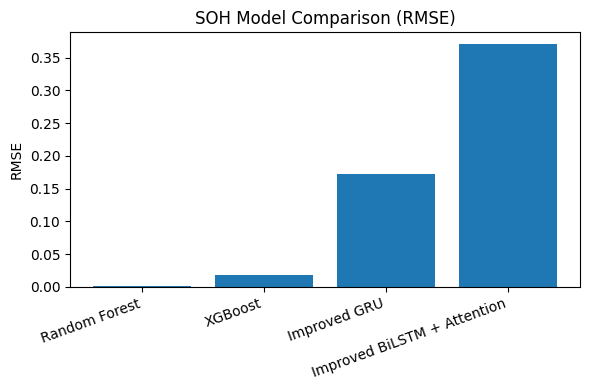

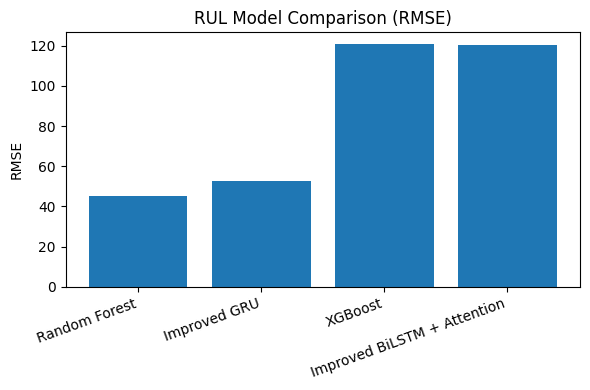

In [86]:
# =========================================================
#  Visualize Model Comparison Results
# =========================================================
import matplotlib.pyplot as plt
import numpy as np

# SOH comparison
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(soh_results_table_v2))
ax.bar(x, soh_results_table_v2["RMSE"])
ax.set_title("SOH Model Comparison (RMSE)")
ax.set_ylabel("RMSE")
ax.set_xticks(x)
ax.set_xticklabels(soh_results_table_v2["Model"], rotation=20, ha="right")
plt.tight_layout()
plt.show()

# RUL comparison
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(rul_results_table_v2))
ax.bar(x, rul_results_table_v2["RMSE"])
ax.set_title("RUL Model Comparison (RMSE)")
ax.set_ylabel("RMSE")
ax.set_xticks(x)
ax.set_xticklabels(rul_results_table_v2["Model"], rotation=20, ha="right")
plt.tight_layout()
plt.show()

#Plot Actual vs Predicted SOH for Selected Batteries

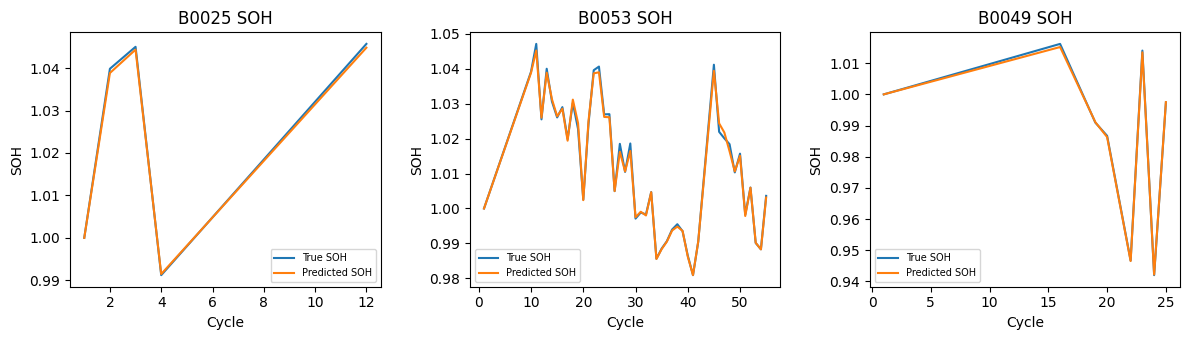

In [89]:
# =========================================================
#  Plot Actual vs Predicted SOH for Selected NASA Batteries
# =========================================================
selected_batteries = ["B0025", "B0053", "B0049"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for ax, batt in zip(axes, selected_batteries):
    batt_df = test_df[test_df["battery_id"] == batt].copy().sort_values("cycle")

    X_batt = scaler_tab.transform(batt_df[feature_cols])
    soh_pred_batt = rf_soh.predict(X_batt)

    ax.plot(batt_df["cycle"], batt_df["SOH"], label="True SOH")
    ax.plot(batt_df["cycle"], soh_pred_batt, label="Predicted SOH")
    ax.set_title(f"{batt} SOH")
    ax.set_xlabel("Cycle")
    ax.set_ylabel("SOH")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

#Plot Actual vs Predicted RUL for Selected NASA Batteries

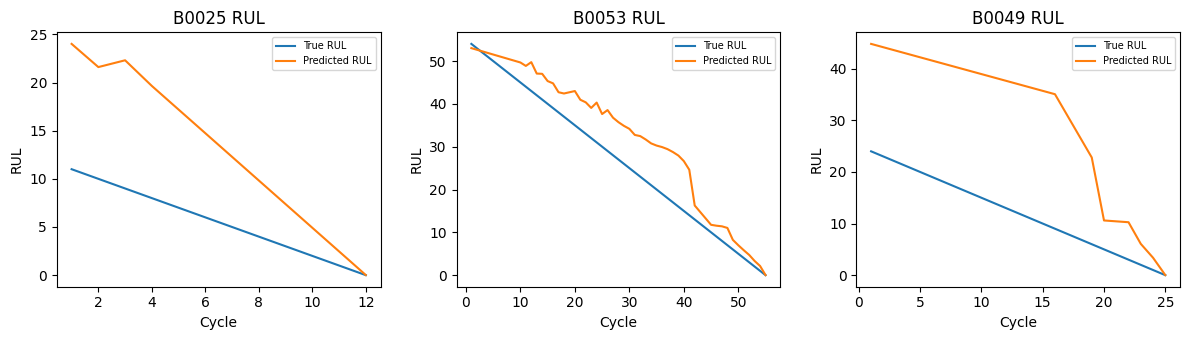

In [90]:
# =========================================================
# Plot Actual vs Predicted RUL for Selected NASA Batteries
# =========================================================
selected_batteries = ["B0025", "B0053", "B0049"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for ax, batt in zip(axes, selected_batteries):
    batt_df = test_df[test_df["battery_id"] == batt].copy().sort_values("cycle")

    X_batt = scaler_tab.transform(batt_df[feature_cols])
    rul_pred_batt = rf_rul.predict(X_batt)

    ax.plot(batt_df["cycle"], batt_df["RUL"], label="True RUL")
    ax.plot(batt_df["cycle"], rul_pred_batt, label="Predicted RUL")
    ax.set_title(f"{batt} RUL")
    ax.set_xlabel("Cycle")
    ax.set_ylabel("RUL")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

#Generate Battery Health Score Using the Final Selected Model

In [ ]:
# =========================================================
# Generate Final Battery Health Score
# =========================================================
# Note:
# Random Forest was selected as the final model because it achieved
# the best overall performance for both SOH and RUL prediction.
# Battery score is computed using SOH and battery-relative RUL ratio
# to avoid scale differences between NASA and Oxford batteries.

def battery_grade(score):
    if score >= 800:
        return "Excellent"
    elif score >= 740:
        return "Very Good"
    elif score >= 670:
        return "Good"
    elif score >= 580:
        return "Fair"
    else:
        return "Poor"

# Build prediction table from final selected model
score_df = test_df[["battery_id", "RUL"]].copy()
score_df["predicted_SOH"] = rf_soh_pred
score_df["predicted_RUL"] = rf_rul_pred

# Keep predictions realistic
score_df["predicted_SOH"] = score_df["predicted_SOH"].clip(0, 1)
score_df["predicted_RUL"] = score_df["predicted_RUL"].clip(lower=0)

# Compute battery-specific maximum RUL from the test set
score_df["battery_max_rul"] = score_df.groupby("battery_id")["RUL"].transform("max")
score_df["battery_max_rul"] = score_df["battery_max_rul"].replace(0, 1)

# Convert predicted RUL into a battery-relative ratio
score_df["predicted_RUL_ratio"] = (
    score_df["predicted_RUL"] / score_df["battery_max_rul"]
).clip(0, 1)

# Aggregate predictions at battery level
battery_score_table = score_df.groupby("battery_id").agg({
    "predicted_SOH": "mean",
    "predicted_RUL": "mean",
    "predicted_RUL_ratio": "mean"
}).reset_index()

# Final score: combine SOH and normalized RUL ratio
battery_score_table["Battery_Health_Score"] = np.round(
    300 + 550 * (
        0.65 * battery_score_table["predicted_SOH"] +
        0.35 * battery_score_table["predicted_RUL_ratio"]
    ),
    0
)

battery_score_table["Battery_Grade"] = battery_score_table["Battery_Health_Score"].apply(battery_grade)

# Format output
battery_score_table["predicted_SOH"] = battery_score_table["predicted_SOH"].round(4)
battery_score_table["predicted_RUL"] = battery_score_table["predicted_RUL"].round(2)
battery_score_table["predicted_RUL_ratio"] = battery_score_table["predicted_RUL_ratio"].round(4)
battery_score_table["Battery_Health_Score"] = battery_score_table["Battery_Health_Score"].round(0)

# Sort best to worst
battery_score_table = battery_score_table.sort_values(
    "Battery_Health_Score", ascending=False
).reset_index(drop=True)

display(battery_score_table)

,battery_id,predicted_SOH,predicted_RUL,predicted_RUL_ratio,Battery_Health_Score,Battery_Grade
0,B0025,0.9983,17.52,0.8002,811.0,Excellent
1,B0053,0.9972,30.07,0.5568,764.0,Very Good
2,Cell6,1.0000,2648.77,0.5298,759.0,Very Good
3,B0049,0.9830,16.63,0.5267,753.0,Very Good
4,B0029,0.9871,13.89,0.3562,721.0,Good
5,B0042,0.8184,53.10,0.4783,685.0,Good
6,B0048,0.7841,38.03,0.5325,683.0,Good
7,B0034,1.0000,0.00,0.0000,657.0,Fair
8,B0052,1.0000,0.00,0.0000,657.0,Fair


#Visualize Battery Health Score in Credit-Style Format

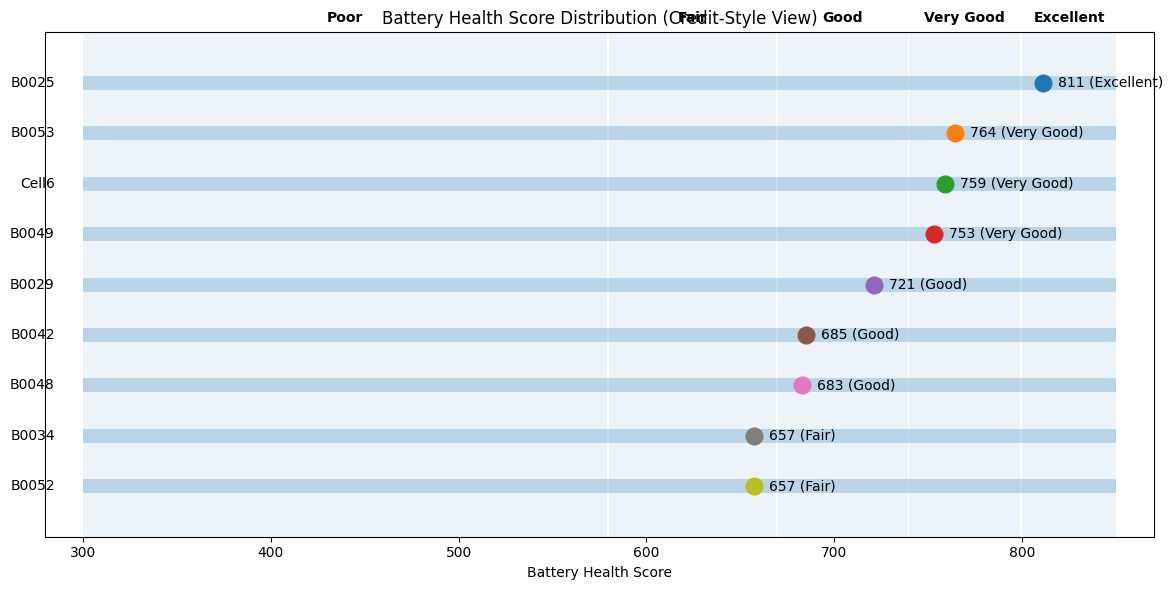

In [83]:
# =========================================================
#  Visualize Battery Health Score in Credit-Style Format
# =========================================================
import matplotlib.pyplot as plt
import numpy as np

score_plot_df = battery_score_table.copy().sort_values(
    "Battery_Health_Score", ascending=False
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))

y_positions = np.arange(len(score_plot_df))[::-1]

bands = [
    (300, 579, "Poor"),
    (580, 669, "Fair"),
    (670, 739, "Good"),
    (740, 799, "Very Good"),
    (800, 850, "Excellent")
]

for start, end, label in bands:
    ax.axvspan(start, end, alpha=0.08)
    ax.text((start + end) / 2, len(score_plot_df) + 0.15, label,
            ha="center", va="bottom", fontsize=10, fontweight="bold")

for i, row in score_plot_df.iterrows():
    y = y_positions[i]

    ax.hlines(y, 300, 850, linewidth=10, alpha=0.25)
    ax.plot(row["Battery_Health_Score"], y, marker="o", markersize=12)

    ax.text(285, y, str(row["battery_id"]), va="center", ha="right", fontsize=10)
    ax.text(row["Battery_Health_Score"] + 8, y,
            f'{row["Battery_Health_Score"]:.0f} ({row["Battery_Grade"]})',
            va="center", fontsize=10)

ax.set_xlim(280, 870)
ax.set_ylim(-1, len(score_plot_df))
ax.set_yticks([])
ax.set_xlabel("Battery Health Score")
ax.set_title("Battery Health Score Distribution (Credit-Style View)")

plt.tight_layout()
plt.show()

#Circular Battery Credit-Style Gauge

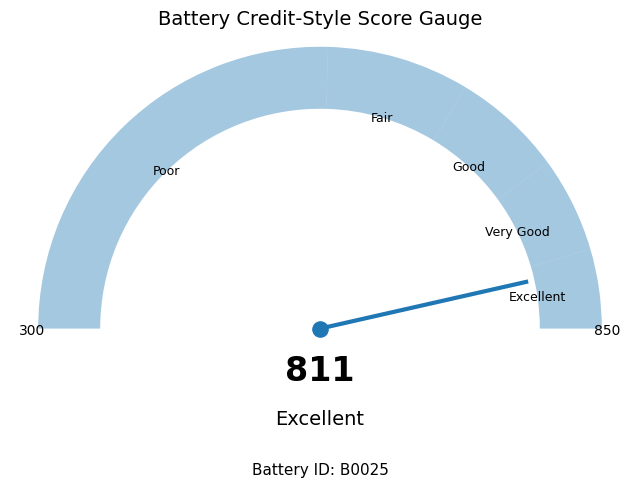

In [84]:
# =========================================================
# Cell 14 - Circular Battery Credit-Style Gauge
# =========================================================
from matplotlib.patches import Wedge
import numpy as np
import matplotlib.pyplot as plt

selected_row = battery_score_table.iloc[0]

score = float(selected_row["Battery_Health_Score"])
battery_id = selected_row["battery_id"]
grade = selected_row["Battery_Grade"]

min_score = 300
max_score = 850

def score_to_angle(score, min_score=300, max_score=850):
    return 180 * (score - min_score) / (max_score - min_score)

angle = score_to_angle(score, min_score, max_score)

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_aspect("equal")
ax.axis("off")

bands = [
    (300, 580, "Poor"),
    (580, 670, "Fair"),
    (670, 740, "Good"),
    (740, 800, "Very Good"),
    (800, 850, "Excellent")
]

for start, end, label in bands:
    start_angle = 180 - score_to_angle(start, min_score, max_score)
    end_angle = 180 - score_to_angle(end, min_score, max_score)

    wedge = Wedge(
        center=(0, 0),
        r=1.0,
        theta1=end_angle,
        theta2=start_angle,
        width=0.22,
        alpha=0.4
    )
    ax.add_patch(wedge)

    mid_score = (start + end) / 2
    mid_angle = np.deg2rad(180 - score_to_angle(mid_score, min_score, max_score))
    x = 0.78 * np.cos(mid_angle)
    y = 0.78 * np.sin(mid_angle)
    ax.text(x, y, label, ha="center", va="center", fontsize=9)

pointer_angle = np.deg2rad(180 - angle)
x_pointer = 0.75 * np.cos(pointer_angle)
y_pointer = 0.75 * np.sin(pointer_angle)

ax.plot([0, x_pointer], [0, y_pointer], linewidth=3)
ax.scatter(0, 0, s=120)

ax.text(0, -0.15, f"{score:.0f}", ha="center", va="center", fontsize=24, fontweight="bold")
ax.text(0, -0.32, grade, ha="center", va="center", fontsize=14)
ax.text(0, -0.50, f"Battery ID: {battery_id}", ha="center", va="center", fontsize=11)

ax.text(-1.02, -0.02, str(min_score), ha="center", fontsize=10)
ax.text(1.02, -0.02, str(max_score), ha="center", fontsize=10)

ax.set_title("Battery Credit-Style Score Gauge", fontsize=14)
plt.show()

#SHAP Explainability for the Final Random Forest Mode

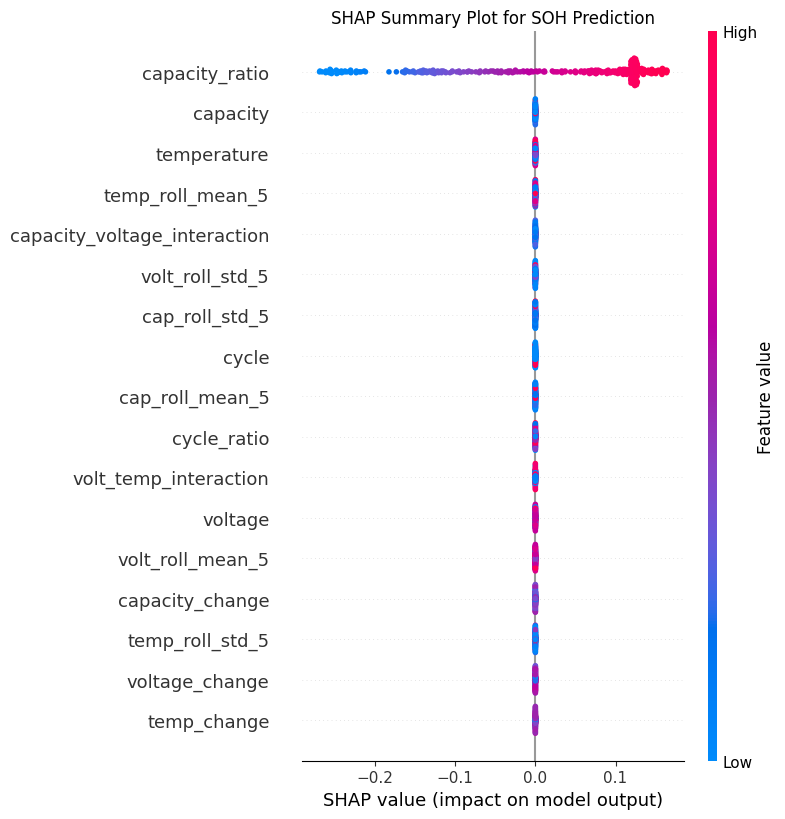

In [91]:
#  SHAP Explainability for the Final Random Forest Model
# =========================================================
# Note:
# SHAP was used to explain which features had the strongest influence
# on the final Random Forest model predictions.

import shap
import matplotlib.pyplot as plt

# Use a sample from test data for SHAP explanation
X_shap = pd.DataFrame(X_test_tab, columns=feature_cols)

explainer_soh = shap.TreeExplainer(rf_soh)
shap_values_soh = explainer_soh.shap_values(X_shap)

plt.figure()
shap.summary_plot(shap_values_soh, X_shap, show=False)
plt.title("SHAP Summary Plot for SOH Prediction")
plt.tight_layout()
plt.show()


#Final Summary and Key Findings

In [94]:
# =========================================================
# Final Summary and Key Findings
# =========================================================
print("Final Summary and Key Findings")
print("- Random Forest achieved the best overall performance for both SOH and RUL prediction.")
print("- XGBoost performed reasonably well, but it was still weaker than Random Forest.")
print("- Deep learning models were explored and improved using feature engineering, augmentation, and hyperparameter tuning.")
print("- Improved GRU showed partial improvement, especially for RUL prediction, but it did not outperform Random Forest.")
print("- Actual vs predicted plots showed that the final model followed the overall SOH and RUL trends well.")
print("- A Battery Health Score was introduced as an interpretable business-friendly output.")
print("- SHAP analysis showed that capacity-related features were the most influential in the final")

Final Summary and Key Findings
- Random Forest achieved the best overall performance for both SOH and RUL prediction.
- XGBoost performed reasonably well, but it was still weaker than Random Forest.
- Deep learning models were explored and improved using feature engineering, augmentation, and hyperparameter tuning.
- Improved GRU showed partial improvement, especially for RUL prediction, but it did not outperform Random Forest.
- Actual vs predicted plots showed that the final model followed the overall SOH and RUL trends well.
- A Battery Health Score was introduced as an interpretable business-friendly output.
- SHAP analysis showed that capacity-related features were the most influential in the final
